/home/user-6/projects/speech-and-audio-processing-course/lab4/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Тишина длилась: 0.06966 секунд.


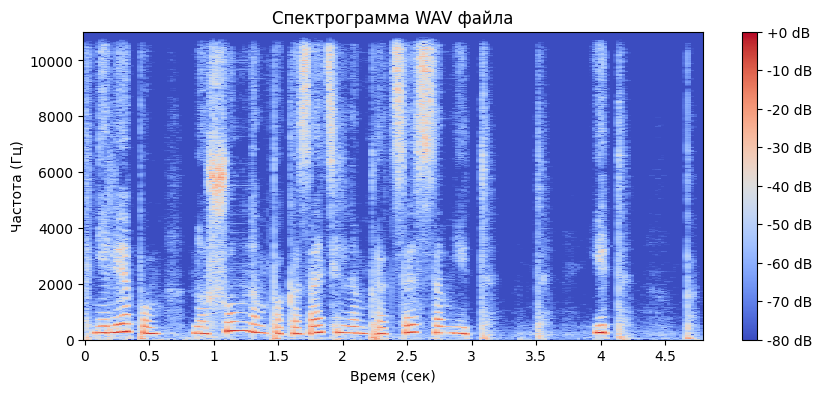

In [2]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Audio, display
from pathlib import Path

ROOT_DIR = Path.cwd().parent
RESULTS_DIR = ROOT_DIR / "results"
AUDIO_DIR = RESULTS_DIR / "audio"

# 1. Загрузка файла
filename = 'silero_tts_v4_ru_abbr_graphic_abbr_graphic_05.wav'
file_path = str(AUDIO_DIR / filename)
y, sr = librosa.load(file_path)

# 2. Преобразование в спектрограмму (STFT)
stft = librosa.stft(y)
stft_db = librosa.amplitude_to_db(np.abs(stft), ref=np.max)

# 3. Расчёт тишины
# Разделение аудио на звуковые фрагменты (top_db — порог шума в децибелах)
# Чем меньше top_db (например, 20-30), тем чувствительнее алгоритм к тихим звукам
intervals = librosa.effects.split(y, top_db=10)

# Начало первого звукового фрагмента в отсчетах (samples)
first_sound_sample = intervals[0][0]

# Конвертация отсчетов в секунды
time_to_first_sound = librosa.samples_to_time(first_sound_sample, sr=sr)
print(f"Тишина длилась: {time_to_first_sound:.5f} секунд.")

# 4. Вывод аудио
display(Audio(file_path))

# 5. Визуализация
plt.figure(figsize=(10, 4))
librosa.display.specshow(stft_db, sr=sr, x_axis='time', y_axis='hz', cmap='coolwarm')
plt.colorbar(format='%+2.0f dB')
plt.title('Спектрограмма WAV файла')
plt.xlabel('Время (сек)')
plt.ylabel('Частота (Гц)')
plt.show()

In [1]:
import re
import pandas as pd

CSV_PATH = RESULTS_DIR / "manual_scores.csv"
TOP_DB = 10

df = pd.read_csv(CSV_PATH)

if "latency_sec" not in df.columns:
    df["latency_sec"] = pd.Series(pd.NA, index=df.index, dtype="Float64")
else:
    df["latency_sec"] = pd.to_numeric(df["latency_sec"], errors="coerce").astype("Float64")

for col in ["has_error", "error_notes"]:
    if col not in df.columns:
        df[col] = pd.Series(pd.NA, index=df.index, dtype="string")
    else:
        df[col] = df[col].astype("string")

def parse_answer(answer: str):
    """
    Поддерживает форматы:
    - 0.04644 yes в конце поплыл
    - 0.04644 yes
    - 0.04644 no
    """
    answer = answer.strip()
    m = re.match(r"^([0-9]*\.?[0-9]+)\s+(yes|no)(?:\s+(.*))?$", answer, flags=re.IGNORECASE)
    if not m:
        raise ValueError("Неверный формат")
    
    latency_sec = float(m.group(1))
    has_error = m.group(2).lower()
    error_notes = m.group(3).strip() if m.group(3) else ""
    return latency_sec, has_error, error_notes

def is_marked(row):
    latency_filled = pd.notna(row.get("latency_sec"))
    has_error_filled = pd.notna(row.get("has_error")) and str(row.get("has_error")).strip() != ""
    error_notes_filled = pd.notna(row.get("error_notes")) and str(row.get("error_notes")).strip() != ""
    return latency_filled or has_error_filled or error_notes_filled

for idx, row in df.iterrows():
    if is_marked(row):
        print(f"[{idx}] Уже размечено, пропуск")
        continue

    audio_rel_path = row["audio_path"]
    audio_path = ROOT_DIR / audio_rel_path

    if not audio_path.exists():
        print(f"[{idx}] Файл не найден: {audio_path}")
        continue

    print("=" * 80)
    print(f"Строка {idx}")
    print(f"group: {row.get('group', '')}")
    print(f"item_id: {row.get('item_id', '')}")
    print(f"text: {row.get('text', '')}")
    print()

    y, sr = librosa.load(str(audio_path), sr=None)

    intervals = librosa.effects.split(y, top_db=TOP_DB)
    if len(intervals) > 0:
        first_sound_sample = intervals[0][0]
        time_to_first_sound = float(librosa.samples_to_time(first_sound_sample, sr=sr))
    else:
        time_to_first_sound = float(len(y) / sr)

    print(f"Расчёт тишины: {time_to_first_sound:.5f}")
    print("аудио")
    display(Audio(str(audio_path)))

    while True:
        answer = input("Ввод (`0.04644 yes ...` / `0.04644 yes` / `0.04644 no`): ").strip()
        try:
            latency_sec, has_error, error_notes = parse_answer(answer)
            break
        except ValueError:
            print("Неверный формат. Примеры: `0.04644 yes в конце поплыл`, `0.04644 yes`, `0.04644 no`")

    if str(row.get("group", "")).strip().lower() == "stress":
        print("group=stress, запись пропущена")
        continue

    df.at[idx, "latency_sec"] = latency_sec
    df.at[idx, "has_error"] = has_error
    df.at[idx, "error_notes"] = error_notes if error_notes else pd.NA

    df.to_csv(CSV_PATH, index=False)
    print(f"Сохранено в {CSV_PATH}")
    print()

print("Готово")


NameError: name 'RESULTS_DIR' is not defined

In [5]:
import pandas as pd

CSV_PATH = RESULTS_DIR / "manual_scores.csv"
TOP_DB = 10

df = pd.read_csv(CSV_PATH)

if "latency_sec" not in df.columns:
    df["latency_sec"] = pd.Series(pd.NA, index=df.index, dtype="Float64")
else:
    df["latency_sec"] = pd.to_numeric(df["latency_sec"], errors="coerce").astype("Float64")

if "has_error" not in df.columns:
    df["has_error"] = pd.Series(pd.NA, index=df.index, dtype="string")
else:
    df["has_error"] = df["has_error"].astype("string")

latency_missing_mask = df["latency_sec"].isna()
has_error_missing_mask = df["has_error"].isna() | (df["has_error"].str.strip() == "")

for idx, row in df[latency_missing_mask].iterrows():
    audio_path = ROOT_DIR / row["audio_path"]

    if not audio_path.exists():
        print(f"[{idx}] Файл не найден: {audio_path}")
        continue

    y, sr = librosa.load(str(audio_path), sr=None)
    intervals = librosa.effects.split(y, top_db=TOP_DB)

    if len(intervals) > 0:
        first_sound_sample = intervals[0][0]
        time_to_first_sound = float(librosa.samples_to_time(first_sound_sample, sr=sr))
    else:
        time_to_first_sound = float(len(y) / sr)

    df.at[idx, "latency_sec"] = time_to_first_sound

df.loc[has_error_missing_mask, "has_error"] = "yes"

df.to_csv(CSV_PATH, index=False)

print(f"Заполнено latency_sec: {int(latency_missing_mask.sum())}")
print(f"Заполнено has_error: {int(has_error_missing_mask.sum())}")
print(f"Сохранено в {CSV_PATH}")


Заполнено latency_sec: 31
Заполнено has_error: 31
Сохранено в /home/user-6/projects/speech-and-audio-processing-course/lab4/results/manual_scores.csv
